## 1. Data loading & shape

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the dataset
df = pd.read_csv('Telco-Customer-Churn.csv')
print("Dataset shape:", df.shape)
print("Rows:", df.shape[0], "| Columns:", df.shape[1])

Dataset shape: (7043, 21)
Rows: 7043 | Columns: 21


In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Data quality check

In [5]:
# Understanding column data types
print(df.dtypes)

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Check for missing values
print("Null values:", df.isnull().sum().sum())
print("Empty string check:")
print((df == ' ').sum()[df.columns[(df == ' ').sum() > 0]])

Null values: 0
Empty string check:
TotalCharges    11
dtype: int64


In [8]:
# TotalCharges issue in code 
print("TotalCharges dtype:", df['TotalCharges'].dtype)
invalid = df[df['TotalCharges'] == ' ']
print(f"Rows with blank TotalCharges: {len(invalid)}")
print("These are likely new customers (tenure=0):")
print(invalid[['tenure', 'MonthlyCharges', 'TotalCharges']].head())

TotalCharges dtype: str
Rows with blank TotalCharges: 11
These are likely new customers (tenure=0):
      tenure  MonthlyCharges TotalCharges
488        0           52.55             
753        0           20.25             
936        0           80.85             
1082       0           25.75             
1340       0           56.05             


## 3. Target variable: churn 

In [12]:
# Total customers churned
churn_counts = df['Churn'].value_counts()
churn_rate = (df['Churn'] == 'Yes').mean() * 100
print("Churn counts:", churn_counts)
print(f"Churn rate: {churn_rate:.1f}%")

Churn counts: Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn rate: 26.5%


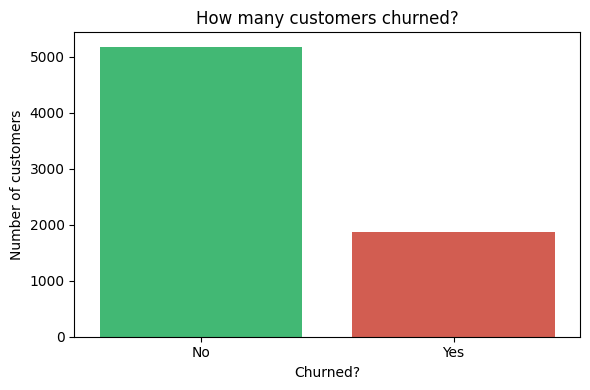

In [13]:
# Visualize Churn distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn', hue='Churn', 
              palette={'No': '#2ecc71', 'Yes': '#e74c3c'},
              legend=False)
plt.title('How many customers churned?')
plt.xlabel('Churned?')
plt.ylabel('Number of customers')
plt.tight_layout()
plt.show()

## 4. Key feature analysis 

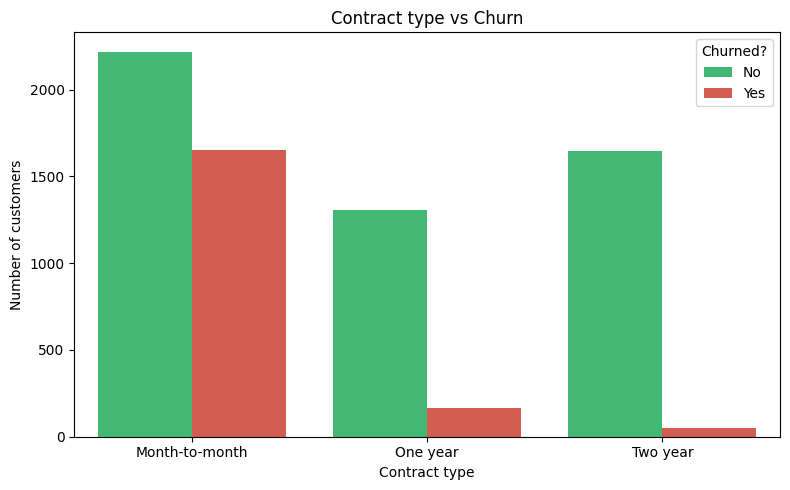

In [14]:
# Churns by contract type
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Contract', hue='Churn',
             palette=['#2ecc71', '#e74c3c'])
plt.title('Contract type vs Churn')
plt.xlabel('Contract type')
plt.ylabel('Number of customers')
plt.legend(title='Churned?')
plt.tight_layout()
plt.show()

In [15]:
# Churn rate by contract type
contract_churn = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).round(1)

print("Churn rate by contract type:")
print(contract_churn)

Churn rate by contract type:
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64


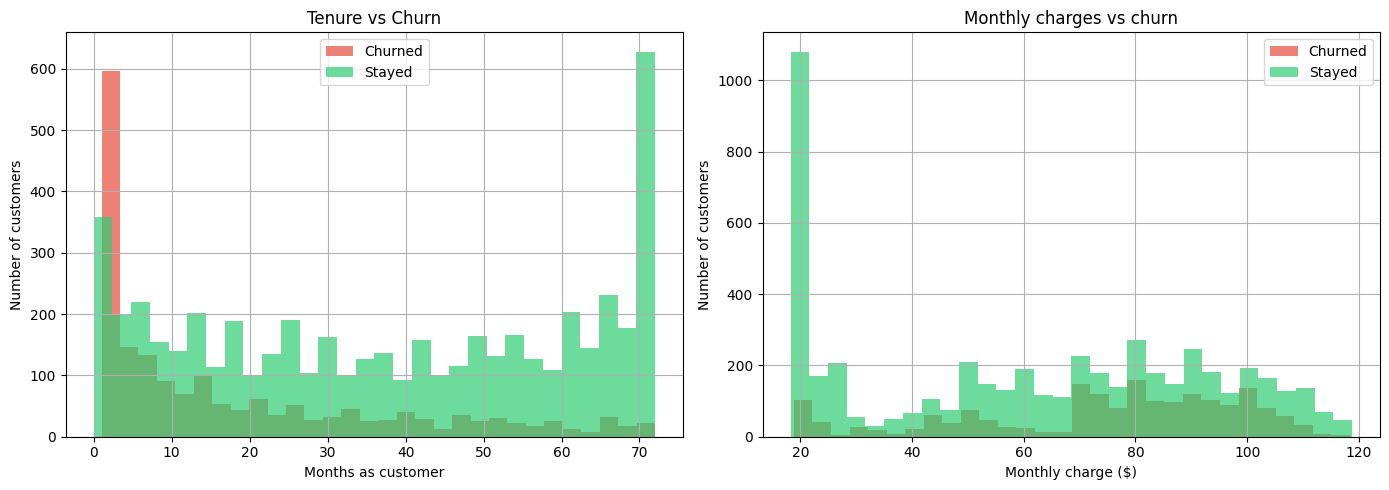

In [16]:
fig, axes = plt.subplots(1,2,figsize=(14,5))

# Churn by Tenure
df[df['Churn']=='Yes']['tenure'].hist(
    bins=30, alpha=0.7, color='#e74c3c', label='Churned', ax=axes[0])
df[df['Churn']=='No']['tenure'].hist(
    bins=30, alpha=0.7, color='#2ecc71', label='Stayed', ax=axes[0])
axes[0].set_title('Tenure vs Churn')
axes[0].set_xlabel('Months as customer')
axes[0].set_ylabel('Number of customers')
axes[0].legend()

# Churn by Monthly charges
df[df['Churn']=='Yes']['MonthlyCharges'].hist(
    bins=30, alpha=0.7, color='#e74c3c', label='Churned', ax=axes[1])
df[df['Churn']=='No']['MonthlyCharges'].hist(
    bins=30, alpha=0.7, color='#2ecc71', label='Stayed', ax=axes[1])
axes[1].set_title('Monthly charges vs churn')
axes[1].set_xlabel('Monthly charge ($)')
axes[1].set_ylabel('Number of customers')
axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:
# Churn rate by internet service type
internet_churn = df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack()
internet_churn['Churn_rate_%'] = (internet_churn['Yes'] * 100).round(1)
print('Churn rate by internet service type:',internet_churn[['Churn_rate_%']])

Churn rate by internet service type: Churn            Churn_rate_%
InternetService              
DSL                      19.0
Fiber optic              41.9
No                        7.4


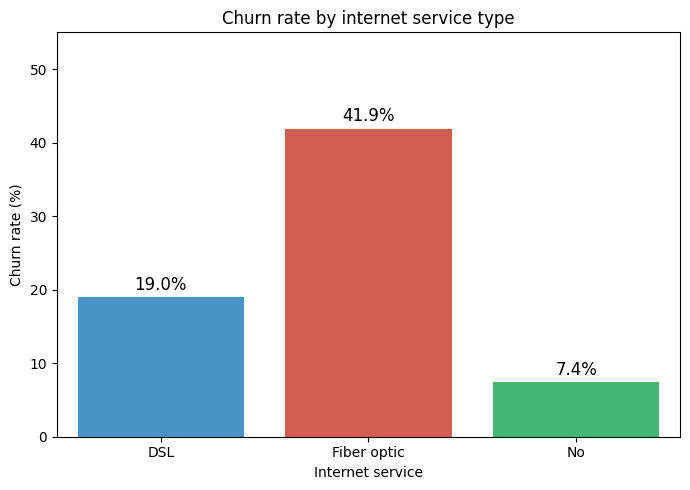

In [18]:
plt.figure(figsize=(7, 5))
churn_by_internet = df.groupby('InternetService')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
churn_by_internet.columns = ['InternetService', 'Churn_rate']

sns.barplot(data=churn_by_internet, x='InternetService', hue='InternetService',
            y='Churn_rate', palette={'DSL':'#3498db','Fiber optic':'#e74c3c','No':'#2ecc71'},
           legend=False)
plt.title('Churn rate by internet service type')
plt.xlabel('Internet service')
plt.ylabel('Churn rate (%)')
plt.ylim(0, 55)

# Add percentage labels on top of each bar
for i, row in churn_by_internet.iterrows():
    plt.text(i, row['Churn_rate'] + 1,
             f"{row['Churn_rate']:.1f}%", ha='center', fontsize=12)

plt.tight_layout()
plt.show()

In [25]:
# Categorical— churn rate across all features 
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'PhoneService', 'MultipleLines', 'InternetService',
            'OnlineSecurity', 'TechSupport', 'Contract', 'PaymentMethod']

rows = []
for col in cat_cols:
    rates = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).round(1)
    for category, rate in rates.items():
        rows.append({'Feature': col, 'Category': category, 'Churn_rate_%': rate})

churn_by_cat = pd.DataFrame(rows).sort_values('Churn_rate_%', ascending=False)
print(churn_by_cat.to_string(index=False))

        Feature                  Category  Churn_rate_%
  PaymentMethod          Electronic check          45.3
       Contract            Month-to-month          42.7
InternetService               Fiber optic          41.9
 OnlineSecurity                        No          41.8
  SeniorCitizen                         1          41.7
    TechSupport                        No          41.6
        Partner                        No          33.0
     Dependents                        No          31.3
  MultipleLines                       Yes          28.6
         gender                    Female          26.9
   PhoneService                       Yes          26.7
         gender                      Male          26.2
  MultipleLines                        No          25.0
   PhoneService                        No          24.9
  MultipleLines          No phone service          24.9
  SeniorCitizen                         0          23.6
        Partner                       Yes       

## 5. Correlation analysis 

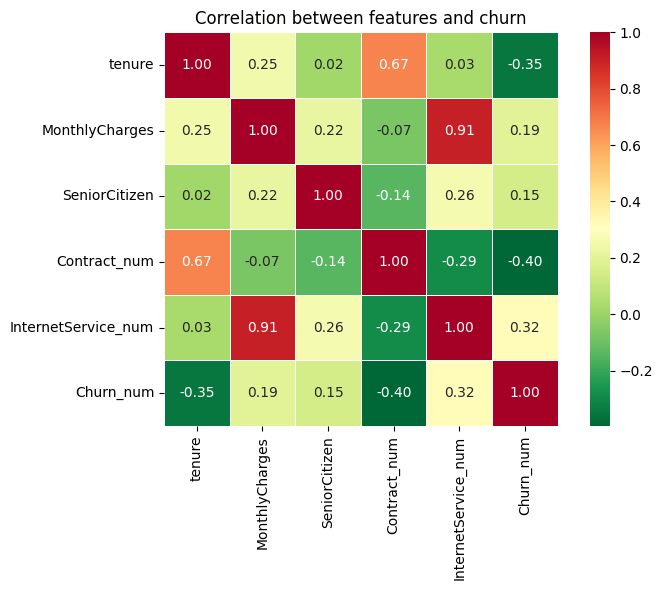

In [29]:
df_temp = df.copy()
df_temp['Churn_num'] = (df_temp['Churn'] == 'Yes').astype(int)
df_temp['Contract_num'] = df_temp['Contract'].map(
    {'Month-to-month': 0, 'One year': 1, 'Two year': 2})
df_temp['InternetService_num'] = df_temp['InternetService'].map(
    {'No': 0, 'DSL': 1, 'Fiber optic': 2})

# Only numeric columns here — no raw string columns
num_cols = ['tenure', 'MonthlyCharges', 'SeniorCitizen', 
            'Contract_num', 'InternetService_num', 'Churn_num']

corr = df_temp[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn_r',
            square=True, linewidths=0.5)
plt.title('Correlation between features and churn')
plt.tight_layout()
plt.show()

## Key findings

1. **Churn rate is 26.5%** - roughly 1 in 4 customers leave.
2. **Electronic check payment is the strongest predictor** — 45.3% churn rate, even higher than month-to-month contracts (42.7%). This may indicate lower customer commitment or financial instability.
3. **New customers are the most at risk** - most churn happens in the first 12 months of tenure.
4. **Higher monthly charges increases churn risk** - customers paying over $65/month churn more frequently.
5. **Fiber optic customers churn more** - likely due to higher cost and more competition in that segment.
6. **TotalCharges column has a data quality issue** - stored as text
   instead of number, will be fixed in preprocessing.
7. **Customers with no internet service are the lowest-risk segment** - TechSupport, OnlineSecurity, and InternetService all converge at 7.4% for this group, confirming it's the same low-churn customer base.